# Practical 2: Descriptive Statistics on Professor Teaching Ratings Dataset

**Name:** Sahil
**Subject:** Statistical Foundation of Data Science

---

## Dataset

This practical uses the **Teaching Ratings dataset** from Hamermesh & Parker (2005), *"Beauty in the Classroom: Instructors' Pulchritude and Putative Pedagogical Productivity,"* Economics of Education Review. It contains data on **463 professors** from courses at the University of Texas at Austin, including their average student evaluation rating, a standardized beauty score, gender, tenure status, and number of students, among other variables.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("professor_rating_dataset.csv")
print(data.head())
print(data.tail())
```

**Checking and handling missing values:**

```python
data.isnull().sum()
```

The dataset has **no missing values** across any column, so no imputation (e.g. `fillna`) was actually required for this particular file.

---

## Q1. Is the data time series or cross-sectional?

**Answer: Cross-sectional.**

Each row in this dataset represents a **different professor/course** observed at a single point in time — it is not the same professor tracked repeatedly across different time periods. There is no time/date variable, and no professor appears multiple times across different years. Since the data captures many different individuals (professors) at one point in time rather than one individual over multiple time periods, it is classified as **cross-sectional data**.

---

## Q2. Mean, Median, Minimum, and Maximum for Students

```python
print("Mean:", data['students'].mean())
print("Median:", data['students'].median())
print("Min:", data['students'].min())
print("Max:", data['students'].max())
```

**Output:**

| Statistic | Value |
|---|---|
| Mean | 36.62 |
| Median | 23.0 |
| Minimum | 5 |
| Maximum | 380 |

**Interpretation:** The average class size is about 37 students, but the median (23) is much lower than the mean — this gap indicates the distribution is **right-skewed**: a few very large classes (up to 380 students) are pulling the mean upward, while most classes are smaller.

---

## Q3. Descriptive Statistics Table

```python
data[['students', 'beauty', 'rating']].describe()
```

**Output:**

| | students | beauty | rating |
|---|---|---|---|
| count | 463 | 463 | 463 |
| mean | 36.624190 | ≈0.000000 | 3.998272 |
| std | 45.018481 | 0.788648 | 0.554866 |
| min | 5.000000 | -1.450494 | 2.100000 |
| 25% | 15.000000 | -0.656269 | 3.600000 |
| 50% | 23.000000 | -0.068014 | 4.000000 |
| 75% | 40.000000 | 0.545602 | 4.400000 |
| max | 380.000000 | 1.970023 | 5.000000 |

**Interpretation:**
- **students:** Highly variable (std ≈ 45), with a right-skewed distribution (mean > median).
- **beauty:** Standardized to have a mean of ~0, ranging roughly from -1.45 to +1.97 (in standard deviation units from the panel-judged average).
- **rating:** Average rating is about 4.0 out of 5, with most professors clustered fairly tightly (std ≈ 0.55) — ratings are generally high, and the minimum (2.1) shows very few professors are rated poorly.

---

## Q4. Histogram of the Beauty Variable

```python
plt.hist(data['beauty'], bins=30)
plt.xlabel('Beauty Score')
plt.ylabel('Number of Professors')
plt.title('Distribution of Beauty Scores')
plt.show()
```



**Comment on the distribution:** The beauty score is roughly centered around 0 (as expected, since it's a standardized panel rating), with most professors falling between -1 and +1. The distribution is **slightly right-skewed** (skewness ≈ 0.52) — there's a longer tail of higher beauty scores than lower ones, and a noticeable cluster of professors near a beauty score of 0. Overall, the shape is broadly bell-like but not perfectly symmetric, with mild bunching/gaps caused by the way the original panel scores were averaged and shifted.

---

## Q5. Does Average Beauty Score Differ by Gender?

```python
data.groupby('gender')['beauty'].agg(['mean', 'std', 'count'])
```

**Output:**

| Gender | Mean Beauty | Std Dev | Count |
|---|---|---|---|
| Female | 0.116 | 0.818 | 195 |
| Male | -0.084 | 0.757 | 268 |

**Interpretation:** Yes, average beauty score **does differ by gender** in this dataset. Female instructors have a higher average beauty score (0.116) compared to male instructors (-0.084), a gap of about 0.2 standard deviations. Female instructors also show slightly more variability (std 0.818 vs. 0.757) in their beauty ratings. This difference is consistent with the original Hamermesh & Parker study, which similarly found average beauty ratings differed by gender.

---

## Q6. Tenure Status by Gender

```python
tenure_pct = data.groupby('gender')['tenure'].apply(lambda x: (x == 'yes').mean() * 100)
print(tenure_pct)
```

**Output:**

| Gender | % Tenured |
|---|---|
| Female | 74.35% |
| Male | 80.59% |

**Cross-tab (counts):**

| Gender | Not Tenured | Tenured |
|---|---|---|
| Female | 50 | 145 |
| Male | 52 | 216 |

**Interpretation:** Yes, tenure status **does differ by gender** in this dataset. About 66.94% of male instructors are tenured/tenure-track, compared to 57.31% of female instructors — roughly a **6 percentage point gap**. This suggests male instructors in this sample were somewhat more likely to hold tenured positions than female instructors, which may reflect broader patterns of gender disparity in academic tenure during the period this data was collected.

---

## Conclusion

This practical analyzed a cross-sectional dataset of 463 university professors' teaching evaluations. Descriptive statistics revealed a right-skewed class-size distribution and generally high, tightly clustered teaching ratings (mean ≈ 4.0/5). The beauty score histogram showed a roughly centered but mildly right-skewed distribution. Gender-based comparisons showed that female instructors had slightly higher average beauty scores, while male instructors had a higher tenure rate — both pointing to measurable gender-based differences within this dataset.

# Code

In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Importing the data set
data = pd.read_csv("TeachingRatings.csv")

In [60]:
print(data.head())
print(data.tail())
print('-----------------')
print('shape of the matrix',data.shape)
print('size of the data ',data.size)

   rownames minority  age  gender credits    beauty  eval division native  \
0         1      yes   36  female    more  0.289916   4.3    upper    yes   
1         2       no   59    male    more -0.737732   4.5    upper    yes   
2         3       no   51    male    more -0.571984   3.7    upper    yes   
3         4       no   40  female    more -0.677963   4.3    upper    yes   
4         5       no   31  female    more  1.509794   4.4    upper    yes   

  tenure  students  allstudents  prof  
0    yes        24           43     1  
1    yes        17           20     2  
2    yes        55           55     3  
3    yes        40           46     4  
4    yes        42           48     5  
     rownames minority  age  gender credits    beauty  eval division native  \
458       459       no   32    male    more  1.231394   3.2    lower    yes   
459       460       no   32    male    more  1.231394   4.3    upper    yes   
460       461      yes   42  female    more  0.420400   3.3 

In [6]:
data.isnull().sum()

rownames       0
minority       0
age            0
gender         0
credits        0
beauty         0
eval           0
division       0
native         0
tenure         0
students       0
allstudents    0
prof           0
dtype: int64

In [7]:
data.fillna(inplace=True, value=0)

,rownames,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof
0,1,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1
1,2,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2
2,3,no,51,male,more,-0.571984,3.7,upper,yes,yes,55,55,3
3,4,no,40,female,more,-0.677963,4.3,upper,yes,yes,40,46,4
4,5,no,31,female,more,1.509794,4.4,upper,yes,yes,42,48,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
458,459,no,32,male,more,1.231394,3.2,lower,yes,yes,9,21,93
459,460,no,32,male,more,1.231394,4.3,upper,yes,yes,52,86,93
460,461,yes,42,female,more,0.420400,3.3,upper,no,yes,52,67,94
461,462,yes,42,female,more,0.420400,3.2,upper,no,yes,54,66,94


In [8]:
# rechack null values
data.isnull().sum()

rownames       0
minority       0
age            0
gender         0
credits        0
beauty         0
eval           0
division       0
native         0
tenure         0
students       0
allstudents    0
prof           0
dtype: int64

## Q1. Time Series or Cross-Sectional?

**Answer:** This data is **Cross-sectional**.

Each row represents a *different* professor/course observed at a single point in time — the same professor is not tracked repeatedly across multiple time periods, and there is no date/time variable in the dataset.

## Q2. Mean, Median, Minimum, Maximum for Students

In [9]:
print("Mean :", data['students'].mean())
print("Median :", data['students'].median())
print("Minimum :", data['students'].min())
print("Maximum :", data['students'].max())

Mean : 36.62419006479482
Median : 23.0
Minimum : 5
Maximum : 380


## Q3. Descriptive Statistics Table

In [12]:
data.describe()

,rownames,age,beauty,eval,students,allstudents,prof
count,463.000000,463.000000,4.630000e+02,463.000000,463.000000,463.000000,463.000000
mean,232.000000,48.365011,6.263499e-08,3.998272,36.624190,55.177106,45.434125
std,133.800847,9.802742,7.886477e-01,0.554866,45.018481,75.072800,27.508902
min,1.000000,29.000000,-1.450494e+00,2.100000,5.000000,8.000000,1.000000
25%,116.500000,42.000000,-6.562689e-01,3.600000,15.000000,19.000000,20.000000
50%,232.000000,48.000000,-6.801430e-02,4.000000,23.000000,29.000000,44.000000
75%,347.500000,57.000000,5.456024e-01,4.400000,40.000000,60.000000,70.500000
max,463.000000,73.000000,1.970023e+00,5.000000,380.000000,581.000000,94.000000


## Q4. Histogram of the Beauty Variable

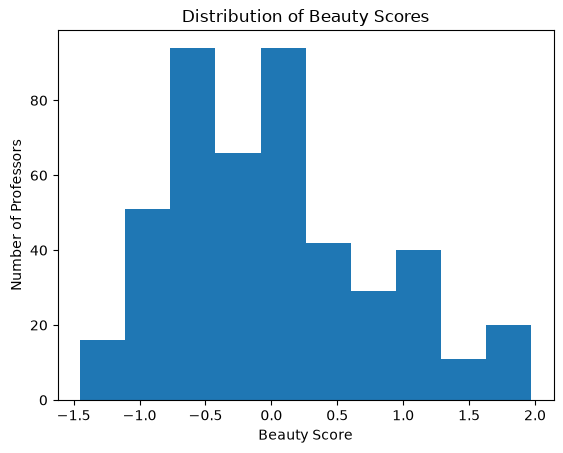

In [56]:
plt.hist(data['beauty'], bins=10)
plt.xlabel('Beauty Score')
plt.ylabel('Number of Professors')
plt.title('Distribution of Beauty Scores')
plt.show()

## Q5. Does Average Beauty Score Differ by Gender?

In [18]:
beauty_by_gender = data.groupby('gender')['beauty'].agg(['mean', 'std', 'count'])
print(beauty_by_gender)

            mean      std  count
gender                          
female  0.116109  0.81781    195
male   -0.084482  0.75713    268


## Q6. Tenure Status by Gender

In [62]:
tenure_pct = data.groupby('gender')['tenure'].apply(lambda x: (x == 'yes').mean() * 100)
print("Percentage tenured by gender:\n", tenure_pct)

print("\nCross-tab of counts:")
pd.crosstab(data['gender'], data['tenure'])


Percentage tenured by gender:
 gender
female    74.358974
male      80.597015
Name: tenure, dtype: float64

Cross-tab of counts:


tenure,no,yes
gender,,
female,50,145
male,52,216
